# Summarized-Reservoir Prediction with XGBoost and Bayesian Optimization

This notebook predicts thermal conductivity (`k`) and effusivity (`eff`) from the
initial post-contact thermal response at one fixed temperature.

It compares interpretable thermal-response features with compact statistical
summaries of each ESN reservoir-unit trajectory. XGBoost models nonlinear feature
interactions, while nested Gaussian-process Bayesian optimization selects ESN
hyperparameters without exposing the outer held-out material to model selection.

LOMO performance is assessed using pooled out-of-fold predictions. Per-material
folds report only metrics that are mathematically defined for a constant target.


# 1. Imports and experiment configuration


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.stats import kurtosis, norm, skew
from sklearn.compose import TransformedTargetRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

#

In [ ]:
FILE_TITLE = "60C"
RANDOM_STATE = 42

# Analyze only the initial post-contact transient.
# All thermal-response features below use this complete interval.
ANALYSIS_WINDOW = (0.0, 5.0)

# Manual ESN settings.
#ESN_RES_SIZE = 20
#ESN_LEAK_RATE = 0.1
#ESN_INPUT_MAGNITUDE = 1.5
#ESN_SPECTRAL_RADIUS = 0.7
#ESN_WASHOUT = 5

#Bayesian Optimal HPs
ESN_RES_SIZE = 20
ESN_LEAK_RATE = 0.191114
ESN_INPUT_MAGNITUDE = 0.313073
ESN_SPECTRAL_RADIUS = 1.19964
ESN_WASHOUT = 0

# Fixed XGBoost settings. Bayesian optimization below selects ESN dynamics;
# keeping the readout fixed makes the ESN comparison identifiable and affordable.
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}

# Bayesian ESN search controls.
                                        ### what are these and is there a prescribed package
BAYES_N_TRIALS = 24
BAYES_N_INITIAL = 8
BAYES_ACQUISITION_CANDIDATES = 1024
BAYES_STABILITY_WEIGHT = 0.25

cwd = Path.cwd().resolve()
data_candidates = [
    cwd / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent.parent / "Warmth Sensor Notebook" / "data" / "02_preprocessed" / FILE_TITLE,
]
DATA_PATH = next((path for path in data_candidates if path.is_dir()), None)
if DATA_PATH is None:
    attempted = "\n".join(str(path) for path in data_candidates)
    raise FileNotFoundError(f"Data directory not found. Tried:\n{attempted}")


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [57]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []

for path in sorted(DATA_PATH.glob("*.csv")):
    frame = pd.read_csv(path)
    missing = required - set(frame.columns)
    if missing:
        warnings.warn(f"Skipping {path.name}; missing {sorted(missing)}")
        continue
    frames.append(frame)

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required)).copy()
DATA["Trial"] = DATA["Trial"].astype(int)

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Overwrite processed-file properties unconditionally.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

DATA["trial_id"] = (
    DATA["Sample"].astype(str) + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

# Literature k should be stable by material. Density may vary across measured
# specimens/trials, so the derived eff target is allowed to vary by trial.
k_counts = DATA.groupby("Sample")["k"].nunique()
if (k_counts != 1).any():
    raise ValueError(
        f"k is not constant within: {k_counts[k_counts != 1].index.tolist()}"
    )

summary = (
    DATA.groupby(["trial_id", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Trials: {DATA['trial_id'].nunique()}")
print(f"Independent materials: {DATA['Sample'].nunique()}")
display(summary.head())


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 17,328
Trials: 84
Independent materials: 14


,trial_id,Sample,Trial,n_timesteps,k,eff
0,aluminum_trial_1,aluminum,1,210,237.0,23958.094665
1,aluminum_trial_2,aluminum,2,230,237.0,23958.094665
2,aluminum_trial_3,aluminum,3,194,237.0,23958.094665
3,aluminum_trial_4,aluminum,4,200,237.0,23958.094665
4,aluminum_trial_5,aluminum,5,210,237.0,23958.094665


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–5 second response after contact. Trials are never aligned using `k` or `eff`.


In [58]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])

In [59]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())

Aligned trials retained: 84


,trial_id,Sample,Trial,contact_time,n_analysis_samples
0,aluminum_trial_1,aluminum,1,9.40070,51
1,aluminum_trial_2,aluminum,2,10.90066,50
2,aluminum_trial_3,aluminum,3,8.10070,51
3,aluminum_trial_4,aluminum,4,7.80070,51
4,aluminum_trial_5,aluminum,5,9.00067,50


## Check several alignments visually


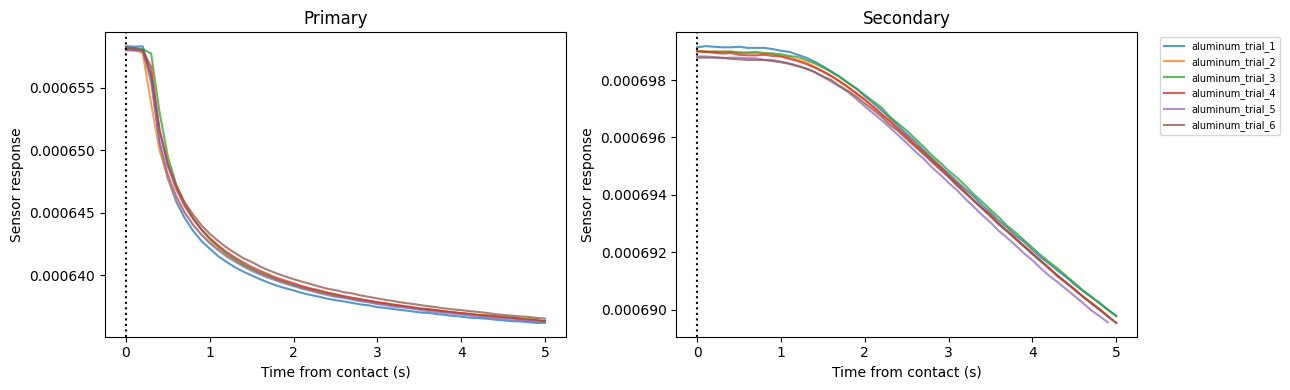

In [60]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])

# 4. Interpretable thermal-response features

Because the analysis interval is 0–5 s, every feature summarizes the complete
transient. The interval is not subdivided into early, middle, and late windows.


In [61]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _response_slope(time, values):
    valid = np.isfinite(time) & np.isfinite(values)
    if valid.sum() < 3:
        return np.nan
    return float(np.polyfit(time[valid], values[valid], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_response_slope"] = _response_slope(time, signal)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 5}")
display(THERMAL_FEATURES.head())


Thermal features: 21


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_response_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,secondary_response_auc,secondary_response_slope,...,difference_max_abs_rate,difference_rate_auc,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Sample,Trial,k,eff
0,-0.000025,0.000025,0.000102,-0.000003,0.000026,0.000025,-0.000009,0.000009,0.000018,-0.000002,...,0.000026,0.000025,0.173943,-0.000038,-0.000054,aluminum_trial_1,aluminum,1,237.0,23958.094665
1,-0.000024,0.000024,0.000096,-0.000003,0.000027,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000027,0.000024,0.176338,-0.000039,-0.000053,aluminum_trial_2,aluminum,2,237.0,23958.094665
2,-0.000024,0.000024,0.000098,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.174287,-0.000039,-0.000053,aluminum_trial_3,aluminum,3,237.0,23958.094665
3,-0.000024,0.000024,0.000097,-0.000003,0.000022,0.000024,-0.000009,0.000009,0.000018,-0.000002,...,0.000022,0.000024,0.183508,-0.000039,-0.000053,aluminum_trial_4,aluminum,4,237.0,23958.094665
4,-0.000024,0.000024,0.000096,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.176910,-0.000039,-0.000053,aluminum_trial_5,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and compact trajectory summaries

For every trial, the reservoir produces a time-by-unit state matrix. This version
does **not** flatten the raw states. Instead, it describes every reservoir-unit
trajectory with nine complementary summaries:

- mean and standard deviation: activation level and variability
- range: peak-to-peak activation magnitude
- net change and linear slope: endpoint change and overall direction
- absolute area: accumulated activation magnitude
- time of maximum absolute activation: timing of the strongest response
- skewness and excess kurtosis: trajectory-distribution shape

Thus, a reservoir with `r` units produces `9 × r` predictors per trial. Removed
summaries were exact or strong proxies of retained quantities over a common time
window (for example, initial/final versus net change; min/max versus range; signed
area versus mean; and mean absolute activation versus absolute area). Time is
retained indirectly through slope, absolute area, peak timing, and net change. Input
scaling is fitted inside each outer training fold.


In [ ]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=0,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError(
                f"Sequence has {len(sequence)} samples, but washout={self.washout}. "
                "Washout must be smaller than the sequence length."
            )
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def summarize_reservoir_trajectories(time, states):
    """Return finite statistical/dynamical summaries for every reservoir unit."""
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    if states.ndim != 2 or len(time) != len(states):
        raise ValueError("Time and reservoir states must have matching rows.")
    if len(time) < 2 or np.any(~np.isfinite(time)) or np.any(np.diff(time) <= 0):
        raise ValueError("Reservoir-state time must be finite and strictly increasing.")
    if np.any(~np.isfinite(states)):
        raise ValueError("Reservoir states contain non-finite values.")

    result = {}
    for unit in range(states.shape[1]):
        values = states[:, unit]
        maximum_absolute_index = int(np.argmax(np.abs(values)))
        standard_deviation = float(np.std(values, ddof=0))

        # Constant or nearly constant trajectories have well-defined zero shape
        # rather than scipy's otherwise undefined skewness/kurtosis warnings.
        if len(values) < 3 or np.isclose(standard_deviation, 0.0):
            skewness = 0.0
        else:
            skewness = float(skew(values, bias=False))
        if len(values) < 4 or np.isclose(standard_deviation, 0.0):
            excess_kurtosis = 0.0
        else:
            excess_kurtosis = float(kurtosis(values, fisher=True, bias=False))

        summaries = {
            "mean": float(np.mean(values)),
            "std": standard_deviation,
            "range": float(np.ptp(values)),
            "net_change": float(values[-1] - values[0]),
            "slope": float(np.polyfit(time, values, 1)[0]),
            "absolute_area": float(np.trapezoid(np.abs(values), time)),
            "time_of_max_absolute": float(time[maximum_absolute_index]),
            "skewness": skewness,
            "excess_kurtosis": excess_kurtosis,
        }
        
        for name, value in summaries.items():
            if not np.isfinite(value):
                raise ValueError(f"Non-finite {name} for reservoir unit {unit}.")
            result[f"esn_{name}_u{unit:03d}"] = value
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [63]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: aluminum_trial_1
Reservoir-state matrix: (51, 20)


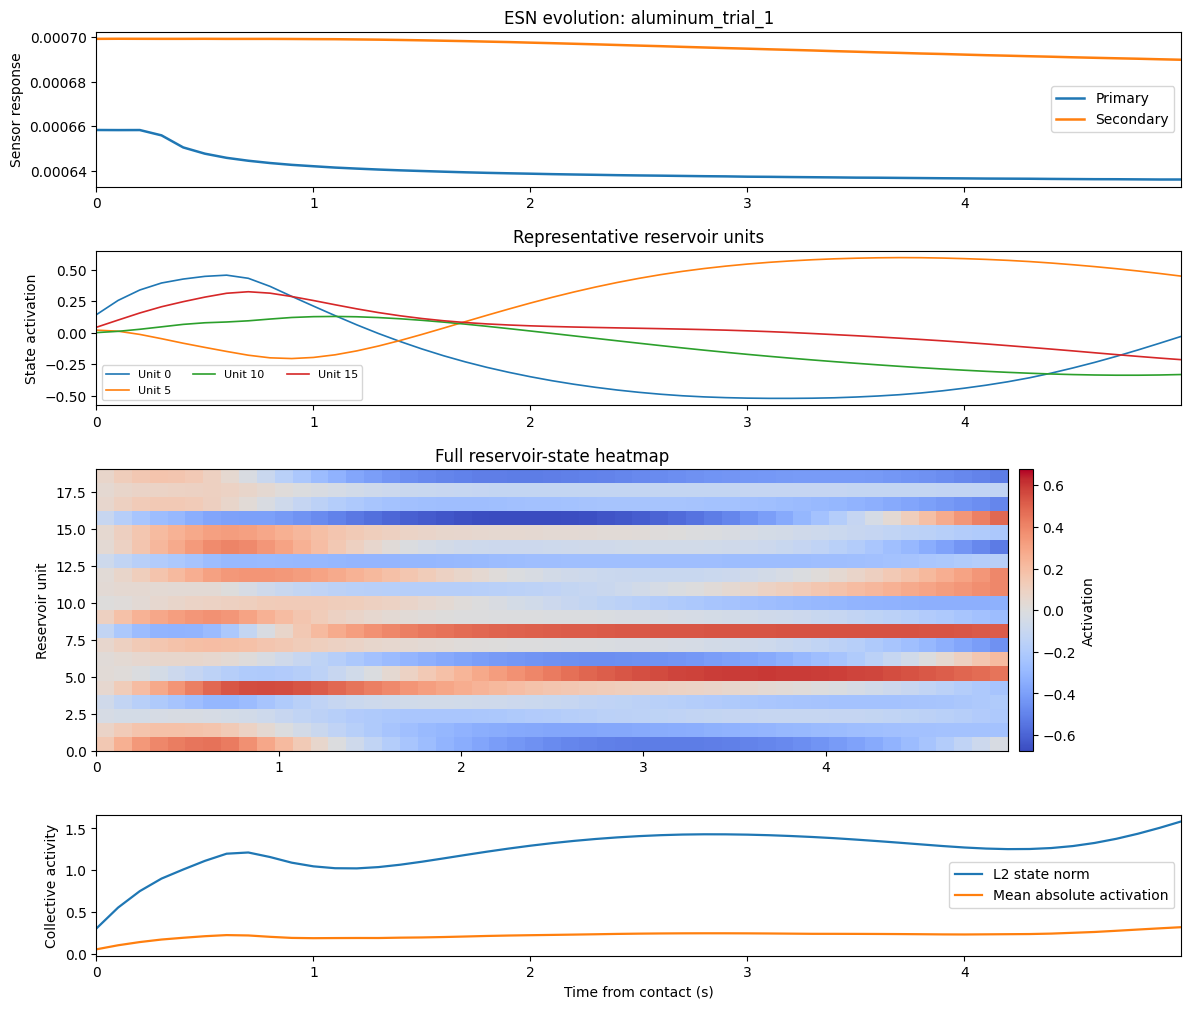

In [64]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe XGBoost regression and valid metrics

For LORO and inner material-grouped validation folds, several target values are
present and ordinary R²/NRMSE-range are defined. A single outer LOMO fold contains
only one held-out material, so its target is constant: fold-level R² and test-range
NRMSE are mathematically undefined and are not reported.

LOMO outer folds instead report MAE, RMSE, bias, median APE, and RMSE normalized by
the **outer-training target range**. Overall R² and NRMSE are computed once from all
pooled out-of-fold material predictions.


In [65]:
def regression_metrics(y_true, y_pred):
    """Metrics requiring variation in y_true; intended for pooled or mixed-target data."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Metrics require non-empty, finite targets and predictions.")
    target_range = float(np.ptp(y_true))
    if len(y_true) < 2 or target_range <= 0:
        raise ValueError(
            "R² and test-range NRMSE require at least two distinct target values. "
            "Use constant_target_fold_metrics for a single-material LOMO fold."
        )
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def constant_target_fold_metrics(y_true, y_pred, training_target_range):
    """Valid diagnostics for one outer LOMO fold with a constant test target."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    training_target_range = float(training_target_range)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Fold metrics require non-empty, finite values.")
    if training_target_range <= 0:
        raise ValueError("The outer-training target range must be positive.")
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return {
        "n": len(y_true),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": rmse,
        "nrmse_training_range": rmse / training_target_range,
        "mean_error_bias": float(np.mean(residual)),
        "median_ape_pct": float(np.median(np.abs(residual / y_true)) * 100),
    }


def make_regressor(xgb_params=None, random_state=RANDOM_STATE):
    params = {**XGB_PARAMS, **(xgb_params or {})}
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_state),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **params,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


# 8. XGBoost evaluation engine


In [66]:
def outer_splits(table, protocol):
    if protocol == "held_out_repetition":
        splitter = GroupKFold(n_splits=table["Trial"].nunique())
        return splitter.split(table, groups=table["Trial"])
    if protocol == "held_out_material":
        splitter = LeaveOneGroupOut()
        return splitter.split(table, groups=table["Sample"])
    raise ValueError("Unknown protocol.")


def build_esn_feature_table(train_ids, all_ids, esn_params=None, random_state=RANDOM_STATE):
    params = {
        "res_size": ESN_RES_SIZE,
        "leak_rate": ESN_LEAK_RATE,
        "input_magnitude": ESN_INPUT_MAGNITUDE,
        "spectral_radius": ESN_SPECTRAL_RADIUS,
        "washout": ESN_WASHOUT,
    }
    params.update(esn_params or {})
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(**params, random_state=random_state)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        states = reservoir.run(sequence)
        state_time = trial["time_from_contact"].to_numpy(float)[params["washout"]:]
        features = summarize_reservoir_trajectories(state_time, states)
        features.update({
            "trial_id": trial_id,
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata = THERMAL_FEATURES[["trial_id", "Sample", "Trial", "k", "eff"]].copy()
    fold_rows, prediction_rows = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()

        if set(train_ids) & set(test_ids):
            raise RuntimeError("Trial leakage detected.")
        if protocol == "held_out_material" and set(train_meta["Sample"]) & set(test_meta["Sample"]):
            raise RuntimeError("Material leakage detected.")

        if feature_family == "thermal":
            fold_features = THERMAL_FEATURES
        elif feature_family == "esn":
            fold_features = build_esn_feature_table(train_ids, train_ids + test_ids)
        else:
            raise ValueError("feature_family must be thermal or esn")

        indexed = fold_features.set_index("trial_id")
        excluded = {"Sample", "Trial", "k", "eff"}
        feature_cols = [
            c for c in fold_features.select_dtypes(include=np.number).columns
            if c not in excluded
        ]
        X_train = indexed.loc[train_ids, feature_cols].reset_index(drop=True)
        X_test = indexed.loc[test_ids, feature_cols].reset_index(drop=True)
        y_train = indexed.loc[train_ids, target].reset_index(drop=True)
        y_test = indexed.loc[test_ids, target].reset_index(drop=True)

        model = make_regressor()
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), y_train.min(), y_train.max())

        if protocol == "held_out_material":
            fold_diagnostics = constant_target_fold_metrics(
                y_test, pred, np.ptp(y_train.to_numpy(float))
            )
        else:
            fold_diagnostics = regression_metrics(y_test, pred)
        fold_rows.append({
            "fold": fold,
            "feature_family": feature_family,
            "target": target,
            "protocol": protocol,
            "test_materials": ", ".join(sorted(set(test_meta["Sample"]))),
            **fold_diagnostics,
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test,
            "y_pred": pred,
        }))

    fold_metrics = pd.DataFrame(fold_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family,
        "target": target,
        "protocol": protocol,
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])
    return fold_metrics, overall, predictions


# 9. Fixed Temperature: held-out repetitions

This protocol tests a new experimental repetition while other trials of the same
materials remain in training. It is the appropriate primary measure of repeatability.


In [67]:
repetition_results = []
repetition_predictions = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_repetition"
        )
        repetition_results.append(overall)
        repetition_predictions[(family, target)] = predictions

REPETITION_RESULTS = pd.concat(repetition_results, ignore_index=True)
display(REPETITION_RESULTS)

,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_repetition,84,44.309567,89.010059,0.221989,0.380700,29.265791
1,thermal,eff,held_out_repetition,84,2767.304016,5420.210246,0.145869,0.766138,12.813648
2,esn,k,held_out_repetition,84,34.755351,74.947414,0.186917,0.560927,21.214675
3,esn,eff,held_out_repetition,84,2230.220683,4623.350517,0.124424,0.829846,13.475990


# 10. Fixed Temperature: held-out materials

Each material is predicted only by a model trained without that material. The main
LOMO R²/NRMSE values are pooled out-of-fold metrics. Per-fold diagnostics are shown
separately to reveal whether a good pooled score hides failures on specific materials.


In [68]:
material_results = []
material_predictions = {}
material_fold_metrics = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predicted = evaluate_feature_family(
            family, target, "held_out_material"
        )
        material_results.append(overall)
        material_predictions[(family, target)] = predicted
        material_fold_metrics[(family, target)] = folds

MATERIAL_RESULTS = pd.concat(material_results, ignore_index=True)
print("Pooled out-of-fold LOMO performance:")
display(MATERIAL_RESULTS)

# Every value below is defined: R² and test-range NRMSE are intentionally absent.
LOMO_PER_FOLD_RESULTS = pd.concat(
    [table for table in material_fold_metrics.values()], ignore_index=True
)
print("Per-material LOMO diagnostics:")
display(LOMO_PER_FOLD_RESULTS.sort_values(
    ["target", "feature_family", "rmse"], ascending=[True, True, False]
))

LOMO_FOLD_STABILITY = (
    LOMO_PER_FOLD_RESULTS
    .groupby(["feature_family", "target", "protocol"], as_index=False)
    .agg(
        folds=("fold", "count"),
        mean_fold_mae=("mae", "mean"),
        sd_fold_mae=("mae", "std"),
        worst_fold_mae=("mae", "max"),
        mean_fold_rmse=("rmse", "mean"),
        sd_fold_rmse=("rmse", "std"),
        worst_fold_rmse=("rmse", "max"),
        mean_fold_nrmse_training_range=("nrmse_training_range", "mean"),
        sd_fold_nrmse_training_range=("nrmse_training_range", "std"),
        worst_fold_nrmse_training_range=("nrmse_training_range", "max"),
    )
)
print("Across-material fold stability summary:")
display(LOMO_FOLD_STABILITY)


Pooled out-of-fold LOMO performance:


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_material,84,56.913367,107.556547,0.268244,0.095733,67.323805
1,thermal,eff,held_out_material,84,3863.948608,6676.813960,0.179687,0.645132,40.325854
2,esn,k,held_out_material,84,53.142739,105.793313,0.263846,0.125138,63.112519
3,esn,eff,held_out_material,84,3680.908449,6651.003691,0.178992,0.647870,35.864183


Per-material LOMO diagnostics:


,fold,feature_family,target,protocol,test_materials,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct
45,4,esn,eff,held_out_material,copper,6,19716.466975,19845.424839,0.829533,-19716.466975,53.169927
49,8,esn,eff,held_out_material,iron,6,8616.729165,10323.493602,0.277826,8616.729165,43.462096
54,13,esn,eff,held_out_material,titanium,6,5392.378230,6021.568051,0.162053,4554.760785,74.615822
42,1,esn,eff,held_out_material,aluminum,6,5639.896098,5694.242869,0.153244,-5639.896098,23.535882
50,9,esn,eff,held_out_material,nickel,6,4088.513320,4676.222601,0.125847,-1359.013267,19.988346
47,6,esn,eff,held_out_material,graphite,6,4334.427723,4384.480292,0.117995,-1393.865853,36.967452
43,2,esn,eff,held_out_material,bismuth,6,2930.382552,2989.375399,0.080450,1495.796461,97.861604
51,10,esn,eff,held_out_material,pdms,6,257.026502,279.771689,0.007529,-257.026502,65.923000
46,5,esn,eff,held_out_material,cork,6,265.927620,267.631378,0.007203,265.927620,203.289908
44,3,esn,eff,held_out_material,cement,6,110.757627,116.881220,0.003146,110.757627,22.265484


Across-material fold stability summary:


,feature_family,target,protocol,folds,mean_fold_mae,sd_fold_mae,worst_fold_mae,mean_fold_rmse,sd_fold_rmse,worst_fold_rmse,mean_fold_nrmse_training_range,sd_fold_nrmse_training_range,worst_fold_nrmse_training_range
0,esn,eff,held_out_material,14,3680.908449,5395.418210,19716.466975,3913.234534,5580.972056,19845.424839,0.126417,0.219734,0.829533
1,esn,k,held_out_material,14,53.142739,88.510123,314.383528,57.957753,91.845914,316.821556,0.183606,0.357972,1.336992
2,thermal,eff,held_out_material,14,3863.948608,5391.907796,18556.367365,4045.427269,5512.231714,18646.139693,0.128699,0.210456,0.779404
3,thermal,k,held_out_material,14,56.913367,86.924115,293.374714,62.027905,91.185904,298.295578,0.191473,0.342531,1.258812


# 11. Compare actual and predicted values


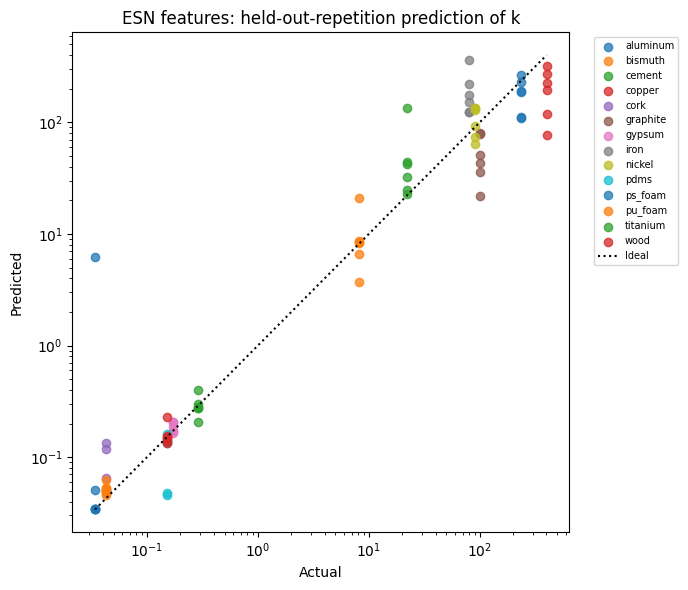

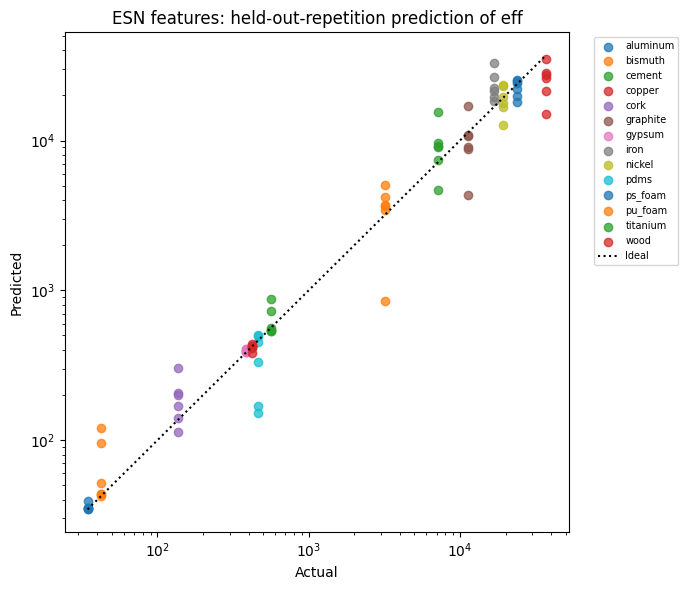

In [69]:
def plot_actual_predicted(predictions, title):
    positive = (predictions["y_true"] > 0) & (predictions["y_pred"] > 0)
    shown = predictions[positive]
    fig, ax = plt.subplots(figsize=(7, 6))
    for material, part in shown.groupby("Sample"):
        ax.scatter(part["y_true"], part["y_pred"], label=material, alpha=0.75)
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], color="black", linestyle=":", label="Ideal")
    ax.set(xscale="log", yscale="log", xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

plot_actual_predicted(
    repetition_predictions[("esn", "k")],
    "ESN features: held-out-repetition prediction of k",
)
plot_actual_predicted(
    repetition_predictions[("esn", "eff")],
    "ESN features: held-out-repetition prediction of eff",
)


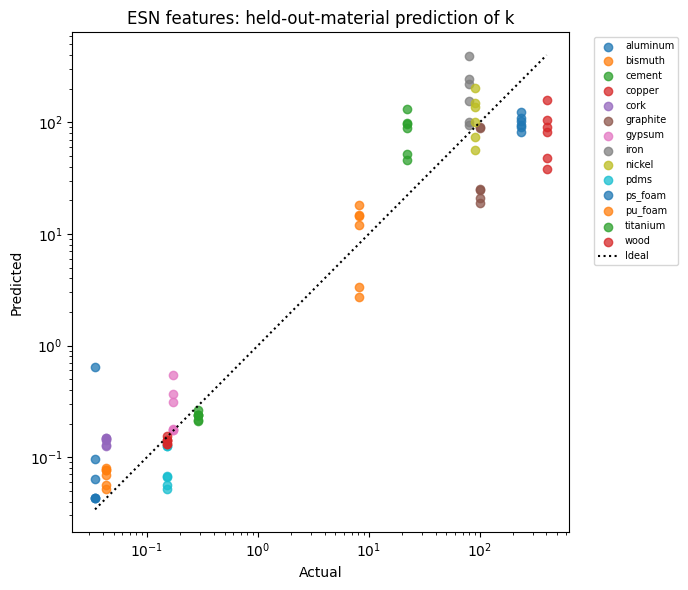

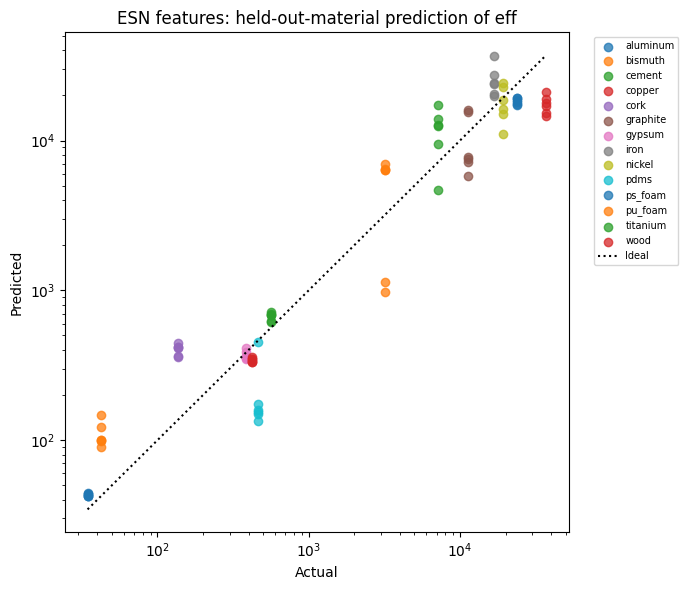

In [70]:
plot_actual_predicted(
    material_predictions[("esn", "k")],
    "ESN features: held-out-material prediction of k",
)
plot_actual_predicted(
    material_predictions[("esn", "eff")],
    "ESN features: held-out-material prediction of eff",
)


# 12. Nested Bayesian optimization of ESN hyperparameters

The objective is generalization to unseen materials. Within every outer LOMO training
set, a Gaussian-process surrogate models the inner-validation loss:

\[
J = \operatorname{mean}(\mathrm{NRMSE}_{inner\ folds})
    + \lambda\,\operatorname{SD}(\mathrm{NRMSE}_{inner\ folds}).
\]

After several random initialization trials, expected improvement chooses promising
ESN configurations. The outer held-out material is never used by the optimizer.
XGBoost settings remain fixed so the search isolates the effects of ESN dynamics.

The reported nested OOF score is an unbiased estimate for the complete selection
procedure. A final Bayesian search on all materials produces deployment parameters;
that final recommendation is not another independent performance estimate.


In [71]:
BAYES_SPACE = {
    "res_size": ("integer", 10, 80),
    "leak_rate": ("float", 0.05, 0.95),
    "input_magnitude": ("float", 0.25, 2.00),
    "spectral_radius": ("float", 0.30, 1.50),
    "washout": ("integer", 0, 5),
}
BAYES_KEYS = tuple(BAYES_SPACE)


def _decode_bayes_point(point):
    """Map a unit-hypercube point to valid ESN parameters."""
    params = {}
    for key, coordinate in zip(BAYES_KEYS, np.clip(point, 0.0, 1.0)):
        kind, low, high = BAYES_SPACE[key]
        value = low + float(coordinate) * (high - low)
        params[key] = int(round(value)) if kind == "integer" else float(value)
    return params


def _predict_esn_fold(train_meta, valid_meta, target, params, random_states):
    train_ids = train_meta["trial_id"].tolist()
    valid_ids = valid_meta["trial_id"].tolist()
    if set(train_ids) & set(valid_ids):
        raise RuntimeError("Trial leakage detected during Bayesian search.")
    if set(train_meta["Sample"]) & set(valid_meta["Sample"]):
        raise RuntimeError("Material leakage detected during Bayesian search.")

    seed_predictions = []
    for random_state in random_states:
        features = build_esn_feature_table(
            train_ids,
            train_ids + valid_ids,
            esn_params=params,
            random_state=random_state,
        ).set_index("trial_id")
        feature_cols = [c for c in features if c.startswith("esn_")]
        X_train = features.loc[train_ids, feature_cols].reset_index(drop=True)
        X_valid = features.loc[valid_ids, feature_cols].reset_index(drop=True)
        y_train = features.loc[train_ids, target].reset_index(drop=True)

        model = make_regressor(random_state=random_state)
        model.fit(X_train, y_train)
        seed_predictions.append(np.clip(
            model.predict(X_valid), y_train.min(), y_train.max()
        ))

    return valid_meta[target].to_numpy(float), np.mean(seed_predictions, axis=0)


def _inner_objective(metadata, target, params, n_splits, random_states, stability_weight):
    splitter = GroupKFold(n_splits=n_splits)
    rows = []
    for fold, (train_idx, valid_idx) in enumerate(
        splitter.split(metadata, groups=metadata["Sample"]), start=1
    ):
        y_true, y_pred = _predict_esn_fold(
            metadata.iloc[train_idx], metadata.iloc[valid_idx],
            target, params, random_states,
        )
        rows.append({"fold": fold, **regression_metrics(y_true, y_pred)})

    fold_metrics = pd.DataFrame(rows)
    values = fold_metrics["nrmse_range"].dropna()
    if values.empty:
        return np.inf, fold_metrics
    mean_nrmse = float(values.mean())
    sd_nrmse = float(values.std(ddof=0))
    return mean_nrmse + stability_weight * sd_nrmse, fold_metrics


def bayesian_optimize_esn(
    metadata,
    target="eff",
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=(42, 43, 44),
    stability_weight=BAYES_STABILITY_WEIGHT,
    acquisition_candidates=BAYES_ACQUISITION_CANDIDATES,
    optimizer_seed=2026,
):
    """Minimize grouped-CV loss using GP expected improvement."""
    if n_trials < 2 or not 1 <= n_initial <= n_trials:
        raise ValueError("Require n_trials >= 2 and 1 <= n_initial <= n_trials.")
    if inner_splits < 2 or inner_splits > metadata["Sample"].nunique():
        raise ValueError("Invalid number of inner material folds.")
    if not random_states:
        raise ValueError("At least one reservoir seed is required.")

    rng = np.random.default_rng(optimizer_seed)
    points, losses, rows = [], [], []

    for trial_number in range(1, n_trials + 1):
        if trial_number <= n_initial:
            point = rng.random(len(BAYES_KEYS))
            acquisition = "random_initialization"
        else:
            X_observed = np.asarray(points)
            y_observed = np.asarray(losses)
            kernel = (
                ConstantKernel(1.0, (1e-2, 1e2))
                * Matern(length_scale=np.ones(len(BAYES_KEYS)), nu=2.5)
                + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
            )
            gp = GaussianProcessRegressor(
                kernel=kernel,
                normalize_y=True,
                random_state=optimizer_seed + trial_number,
                n_restarts_optimizer=2,
            )
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                gp.fit(X_observed, y_observed)
            candidates = rng.random((acquisition_candidates, len(BAYES_KEYS)))
            mean, std = gp.predict(candidates, return_std=True)
            improvement = np.min(y_observed) - mean - 0.01
            z = np.divide(improvement, std, out=np.zeros_like(std), where=std > 0)
            expected_improvement = improvement * norm.cdf(z) + std * norm.pdf(z)
            point = candidates[int(np.argmax(expected_improvement))]
            acquisition = "expected_improvement"

        params = _decode_bayes_point(point)
        loss, fold_metrics = _inner_objective(
            metadata, target, params, inner_splits,
            tuple(random_states), stability_weight,
        )
        points.append(point)
        losses.append(loss)
        rows.append({
            "trial": trial_number,
            "acquisition": acquisition,
            **params,
            "mean_inner_nrmse": float(fold_metrics["nrmse_range"].mean()),
            "sd_inner_nrmse": float(fold_metrics["nrmse_range"].std(ddof=0)),
            "mean_inner_r2": float(fold_metrics["r2"].mean()),
            "performance_index": loss,
        })
        print(f"  Bayesian trial {trial_number:02d}/{n_trials}: J={loss:.4f}")

    history = pd.DataFrame(rows).sort_values("performance_index").reset_index(drop=True)
    best_params = {key: history.loc[0, key] for key in BAYES_KEYS}
    best_params["res_size"] = int(best_params["res_size"])
    best_params["washout"] = int(best_params["washout"])
    return history, best_params


def nested_lomo_bayesian_esn_search(
    target="eff",
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=(42, 43, 44),
    stability_weight=BAYES_STABILITY_WEIGHT,
):
    metadata = THERMAL_FEATURES[
        ["trial_id", "Sample", "Trial", "k", "eff"]
    ].reset_index(drop=True)
    outer_splitter = LeaveOneGroupOut()
    search_rows, outer_rows, prediction_rows = [], [], []

    splits = list(outer_splitter.split(metadata, groups=metadata["Sample"]))
    for outer_fold, (train_idx, test_idx) in enumerate(splits, start=1):
        outer_train = metadata.iloc[train_idx].reset_index(drop=True)
        outer_test = metadata.iloc[test_idx].reset_index(drop=True)
        held_out = outer_test["Sample"].iloc[0]
        print(f"Outer fold {outer_fold}/{len(splits)}: held out {held_out}")

        history, best_params = bayesian_optimize_esn(
            outer_train,
            target=target,
            n_trials=n_trials,
            n_initial=n_initial,
            inner_splits=inner_splits,
            random_states=random_states,
            stability_weight=stability_weight,
            optimizer_seed=2026 + outer_fold,
        )
        history.insert(0, "outer_fold", outer_fold)
        history.insert(1, "held_out_material", held_out)
        search_rows.append(history)

        y_true, y_pred = _predict_esn_fold(
            outer_train, outer_test, target, best_params, tuple(random_states)
        )
        outer_diagnostics = constant_target_fold_metrics(
            y_true,
            y_pred,
            np.ptp(outer_train[target].to_numpy(float)),
        )
        outer_rows.append({
            "outer_fold": outer_fold,
            "held_out_material": held_out,
            **best_params,
            **outer_diagnostics,
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": outer_test["trial_id"].to_numpy(),
            "Sample": outer_test["Sample"].to_numpy(),
            "Trial": outer_test["Trial"].to_numpy(),
            "outer_fold": outer_fold,
            "y_true": y_true,
            "y_pred": y_pred,
        }))

    searches = pd.concat(search_rows, ignore_index=True)
    outer_results = pd.DataFrame(outer_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    nested_metrics = pd.DataFrame([{
        "target": target,
        "protocol": "nested_lomo_bayesian_xgboost",
        "n_bayesian_trials": n_trials,
        "random_states": tuple(random_states),
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])

    print("Final Bayesian search on all materials for deployment parameters")
    final_history, recommended = bayesian_optimize_esn(
        metadata,
        target=target,
        n_trials=n_trials,
        n_initial=n_initial,
        inner_splits=inner_splits,
        random_states=random_states,
        stability_weight=stability_weight,
        optimizer_seed=4042,
    )
    return searches, outer_results, predictions, nested_metrics, final_history, recommended


In [72]:
BAYES_TARGET = "eff"  # Run separately for "k" if conductivity is also a target.
RANDOM_STATES = (42,)# 43, 44)

# Runtime is approximately proportional to:
# outer materials × Bayesian trials × inner folds × reservoir seeds.
# For a quick code check only, use BAYES_N_TRIALS=8, BAYES_N_INITIAL=4,
# inner_splits=3, and RANDOM_STATES=(42,).
(
    BAYES_SEARCH_HISTORY,
    BAYES_OUTER_RESULTS,
    BAYES_PREDICTIONS,
    BAYES_NESTED_METRICS,
    BAYES_FINAL_HISTORY,
    RECOMMENDED_ESN_PARAMETERS,
) = nested_lomo_bayesian_esn_search(
    target=BAYES_TARGET,
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=RANDOM_STATES,
    stability_weight=BAYES_STABILITY_WEIGHT,
)

print("Unbiased nested-LOMO performance:")
display(BAYES_NESTED_METRICS)
print("Per-material outer-fold results:")
display(BAYES_OUTER_RESULTS)
BAYES_OUTER_STABILITY = pd.DataFrame([{
    "folds": len(BAYES_OUTER_RESULTS),
    "mean_fold_mae": BAYES_OUTER_RESULTS["mae"].mean(),
    "sd_fold_mae": BAYES_OUTER_RESULTS["mae"].std(ddof=1),
    "worst_fold_mae": BAYES_OUTER_RESULTS["mae"].max(),
    "mean_fold_rmse": BAYES_OUTER_RESULTS["rmse"].mean(),
    "sd_fold_rmse": BAYES_OUTER_RESULTS["rmse"].std(ddof=1),
    "worst_fold_rmse": BAYES_OUTER_RESULTS["rmse"].max(),
    "mean_fold_nrmse_training_range": BAYES_OUTER_RESULTS["nrmse_training_range"].mean(),
    "sd_fold_nrmse_training_range": BAYES_OUTER_RESULTS["nrmse_training_range"].std(ddof=1),
    "worst_fold_nrmse_training_range": BAYES_OUTER_RESULTS["nrmse_training_range"].max(),
}])
print("Nested LOMO stability across held-out materials:")
display(BAYES_OUTER_STABILITY)
print("Recommended ESN parameters for a future fitted model:")
display(pd.Series(RECOMMENDED_ESN_PARAMETERS))
print("Best trials from the final Bayesian search:")
display(BAYES_FINAL_HISTORY.head(10))


Outer fold 1/14: held out aluminum
  Bayesian trial 01/24: J=1.0092
  Bayesian trial 02/24: J=1.1632
  Bayesian trial 03/24: J=1.3288
  Bayesian trial 04/24: J=0.3046
  Bayesian trial 05/24: J=0.3236
  Bayesian trial 06/24: J=1.5862
  Bayesian trial 07/24: J=1.0634
  Bayesian trial 08/24: J=1.0185
  Bayesian trial 09/24: J=1.0527
  Bayesian trial 10/24: J=1.4387
  Bayesian trial 11/24: J=1.1762
  Bayesian trial 12/24: J=0.2603
  Bayesian trial 13/24: J=0.2793
  Bayesian trial 14/24: J=2.3342
  Bayesian trial 15/24: J=0.8269
  Bayesian trial 16/24: J=1.3119
  Bayesian trial 17/24: J=1.1136
  Bayesian trial 18/24: J=0.9523
  Bayesian trial 19/24: J=1.1234
  Bayesian trial 20/24: J=1.1034
  Bayesian trial 21/24: J=1.6808
  Bayesian trial 22/24: J=1.1907
  Bayesian trial 23/24: J=1.7135
  Bayesian trial 24/24: J=1.1137
Outer fold 2/14: held out bismuth
  Bayesian trial 01/24: J=2.5264
  Bayesian trial 02/24: J=1.3131
  Bayesian trial 03/24: J=3.0254
  Bayesian trial 04/24: J=2.1335
  Bayes

,target,protocol,n_bayesian_trials,random_states,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,eff,nested_lomo_bayesian_xgboost,24,"(42,)",84,3722.286886,6745.593813,0.181538,0.637783,41.627918


Per-material outer-fold results:


,outer_fold,held_out_material,res_size,leak_rate,input_magnitude,spectral_radius,washout,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct
0,1,aluminum,66,0.685102,1.674340,1.030232,1,6,6524.616150,6553.503899,0.176368,-6524.616150,27.175705
1,2,bismuth,42,0.539433,0.937380,1.329474,4,6,1496.873559,2006.253434,0.053992,1496.873559,21.558300
2,3,cement,66,0.084571,0.978647,1.197418,3,6,173.854179,174.195834,0.004688,-173.854179,31.895173
3,4,copper,40,0.767589,1.633310,0.752794,0,6,19902.786148,20019.842782,0.836824,-19902.786148,53.899318
4,5,cork,36,0.369981,0.724834,0.881861,3,6,212.280884,223.796935,0.006023,212.280884,166.272439
5,6,graphite,19,0.735888,0.437009,0.668660,4,6,4007.931863,4496.020499,0.120997,-1477.988981,35.010110
6,7,gypsum,74,0.845251,1.735051,0.646044,3,6,122.452779,124.471034,0.003350,122.452779,29.529809
7,8,iron,74,0.494551,1.978630,1.237640,1,6,8115.088215,9284.742613,0.249871,8115.088215,47.166273
8,9,nickel,46,0.706793,1.626129,1.098769,4,6,5306.983860,6581.624713,0.177125,855.011635,28.029318
9,10,pdms,35,0.621134,1.605096,1.174714,4,6,265.062350,284.321603,0.007652,-249.632688,63.387830


Nested LOMO stability across held-out materials:


,folds,mean_fold_mae,sd_fold_mae,worst_fold_mae,mean_fold_rmse,sd_fold_rmse,worst_fold_rmse,mean_fold_nrmse_training_range,sd_fold_nrmse_training_range,worst_fold_nrmse_training_range
0,14,3722.286886,5475.794269,19902.786148,4024.1372,5618.177775,20019.842782,0.129587,0.221234,0.836824


Recommended ESN parameters for a future fitted model:


res_size           58.000000
leak_rate           0.505759
input_magnitude     0.334427
spectral_radius     1.359355
washout             0.000000
dtype: float64

Best trials from the final Bayesian search:


,trial,acquisition,res_size,leak_rate,input_magnitude,spectral_radius,washout,mean_inner_nrmse,sd_inner_nrmse,mean_inner_r2,performance_index
0,9,expected_improvement,58,0.505759,0.334427,1.359355,0,0.229554,0.059978,0.660807,0.244548
1,10,expected_improvement,78,0.318633,0.696098,1.469820,0,0.231893,0.082347,0.635400,0.252480
2,15,expected_improvement,46,0.598357,0.877219,1.284420,0,0.256857,0.052980,0.590871,0.270102
3,1,random_initialization,17,0.480862,0.591007,1.108653,0,0.301092,0.096261,0.405809,0.325158
4,7,random_initialization,51,0.168106,0.762218,0.478671,0,0.545217,0.596920,-2.788779,0.694447
5,3,random_initialization,71,0.068579,0.561817,1.284510,1,0.572301,0.592976,-2.939906,0.720545
6,17,expected_improvement,46,0.596876,1.531908,0.319872,2,0.625088,0.730427,-4.355298,0.807695
7,2,random_initialization,50,0.330248,0.789414,1.336348,1,0.646176,0.740109,-4.594168,0.831203
8,16,expected_improvement,78,0.063652,0.858223,0.852996,0,0.648611,0.772621,-4.894227,0.841766
9,14,expected_improvement,50,0.949825,1.379493,0.869774,4,0.665757,0.757026,-4.889317,0.855014


## Reading the Bayesian-search and per-fold results

- `BAYES_NESTED_METRICS` is the unbiased pooled OOF estimate for the complete nested
  selection procedure.
- `BAYES_OUTER_RESULTS` contains valid diagnostics for every held-out material:
  MAE, RMSE, training-range NRMSE, bias, and median APE.
- Fold-level LOMO R² is absent by design because a single material has a constant
  target; reporting a numeric value there would be mathematically invalid.
- Compare the mean, standard deviation, and worst per-material error. A strong pooled
  score accompanied by unstable or extreme fold errors is evidence of weak robustness.
- `RECOMMENDED_ESN_PARAMETERS` is for fitting a future model; its inner-CV score is
  not an additional independent test score.


# 13. Interpretation rules

- Each trial becomes one row of compact ESN trajectory summaries; raw states are not predictors.
- With `r` units, the ESN family contains `9 × r` candidate features before XGBoost selection.
- High held-out-repetition performance measures repeatability for represented materials.
- Only pooled out-of-fold LOMO performance supports a claim about unseen materials.
- Pooled OOF R²/NRMSE and per-material error stability must be interpreted together.
- A per-material LOMO fold cannot have a valid R² or test-range NRMSE because its target is constant.
- Bayesian ESN optimization happens only inside each outer training set.
- Multiple reservoir seeds reduce dependence on one random reservoir realization.
- XGBoost can overfit a small material set; inspect worst-fold errors and fold variability.
- Bayesian optimization finds the best observed configuration, not a guaranteed global optimum.
